# DOM 48장 일괄 테스트 — 탐지(YOLO+SAHI) + 분류(ConvNeXt) + 회전 보정

## 이 노트북의 역할
ATRNet-STAR Sandstone DOM 풀씬 **48장(방위각 12 × 편파 4)** 전부에 2단계 파이프라인을 적용해
**검증된 회전 보정**과 함께 정량평가하고, 방위각×편파 표/히트맵으로 패턴을 본다.

## 회전 보정 (before/after로 검증 완료)
DOM은 북쪽 고정 지오코딩이라 비0° 방위각 장면은 학습 칩(radar-frame)과 방향이 어긋난다.
→ **회전 = 방위각을 가장 가까운 90°로 (무손실 np.rot90)**, **180° 모호성은 E2E로 결정**.
(방위각 값 그대로 회전하던 기존 방식의 버그를 교정한 버전. E2E 0.39→0.50 검증됨.)

## 사용 모델/설정
- 탐지기 `checkpoints/yolo_detector.pt` (conf 0.5, SAHI 타일 256/overlap 0.25/100px 필터)
- 분류기 `checkpoints/convnext_soc50_final.pth` (ConvNeXt-Tiny, 50종) — ResNet18 버전(dom48_resnet18)과 비교용

## 사전 준비 (드라이브 `MyDrive/ATRNet-STAR/`)
- `dom_scenes.tar` (DOM 48장 + Annotation xml)
- `checkpoints/yolo_detector.pt`, `checkpoints/convnext_soc50_final.pth`
- `results/resnet18_soc50.json` (클래스 순서)
- 런타임 → **T4 GPU** (48장 × 2회전 ≈ 10~20분)

## 1. 환경 준비

In [ ]:
import torch
from google.colab import drive
drive.mount('/content/drive')

!pip -q install ultralytics sahi

SAVE_DIR = "/content/drive/MyDrive/ATRNet-STAR"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device, "/", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 11.2 MB/s eta 0:00:00
device: cuda / Tesla T4


## 2. DOM 48장 준비 + 메타(방위각/편파) 파싱

In [ ]:
import os, glob, re

if not os.path.exists("/content/raw_scenes"):
    !cp "{SAVE_DIR}/dom_scenes.tar" /content/dom_scenes.tar
    !tar -xf /content/dom_scenes.tar -C /content/ && rm /content/dom_scenes.tar

dom_tifs = sorted(glob.glob("/content/raw_scenes/**/DOM*.tif", recursive=True))

POLMAP = {"H1H1": "HH", "H1V1": "HV", "V1H1": "VH", "V1V1": "VV"}
def scene_meta(path):
    folder = path.split("/")[-2]                 # 예: 30deg_150azi_ID9
    fname  = os.path.basename(path)              # 예: DOM_KuSAR_H1H1_STR1_azbias1024.tif
    azi = int(re.search(r"(\d+)azi", folder).group(1))
    dep = int(re.search(r"(\d+)deg", folder).group(1))
    parts = fname.split("_")
    return dict(path=path, folder=folder, azi=azi, dep=dep,
                band=parts[1].replace("SAR", ""), pol=POLMAP.get(parts[2], parts[2]))

meta = [scene_meta(p) for p in dom_tifs]
print(f"DOM {len(dom_tifs)}장 | 방위각 {sorted(set(m['azi'] for m in meta))} | 편파 {sorted(set(m['pol'] for m in meta))}")

DOM 48장 | 방위각 [0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330] | 편파 ['HH', 'HV', 'VH', 'VV']


## 3. 모델 로드 (탐지기 + 분류기)
분류기를 바꾸려면 이 셀의 **분류기 블록만** 교체 (ConvNeXt 예시는 주석 참고).

In [ ]:
import json
import torch.nn as nn
from torchvision.models import convnext_tiny
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction

# ===== 탐지기 =====
det_model = AutoDetectionModel.from_pretrained(
    model_type="ultralytics",
    model_path=f"{SAVE_DIR}/checkpoints/yolo_detector.pt",
    confidence_threshold=0.5,
    device="cuda:0" if torch.cuda.is_available() else "cpu",
    image_size=256,
)

# ===== 클래스 순서 =====
try:
    with open(f"{SAVE_DIR}/results/resnet18_soc50.json") as f:
        CLASS_NAMES = json.load(f)["classes"]
except FileNotFoundError:
    if not os.path.exists("/content/SOC_50classes"):
        !cp "{SAVE_DIR}/soc50.tar" /content/soc50.tar
        !tar -xf /content/soc50.tar -C /content/ && rm /content/soc50.tar
    CLASS_NAMES = sorted(os.listdir("/content/SOC_50classes/test"))
NUM_CLASSES = len(CLASS_NAMES)

# ===== 분류기 (ConvNeXt-Tiny) — 교체 지점 =====
classifier = convnext_tiny()
classifier.classifier[2] = nn.Linear(classifier.classifier[2].in_features, NUM_CLASSES)
classifier.load_state_dict(torch.load(f"{SAVE_DIR}/checkpoints/convnext_soc50_final.pth",
                                      map_location=device))
classifier = classifier.to(device).eval()
CLS_RESIZE = 128   # ConvNeXt-Tiny=128 (학습과 동일)
print("분류기: convnext_soc50 / 클래스", NUM_CLASSES)

# --- ResNet18로 되돌리려면 ---
# from torchvision.models import resnet18
# classifier = resnet18()
# classifier.fc = nn.Linear(classifier.fc.in_features, NUM_CLASSES)
# classifier.load_state_dict(torch.load(f"{SAVE_DIR}/checkpoints/resnet18_soc50_final.pth", map_location=device))
# classifier = classifier.to(device).eval(); CLS_RESIZE = 128

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
분류기: convnext_soc50 / 클래스 50


## 4. 공통 함수 — 무손실 90° 회전 + 탐지/분류/평가
- `rot_k`: np.rot90으로 90°×k 회전 (무손실, 보간 없음)
- `inv_box`: 회전 프레임 박스 → 원본 좌표 (정수 역변환, 자기검증 포함)
- `eval_at_k`: k회전 후 탐지 → GT 매칭 recall + 매칭 표적 분류정확도

In [ ]:
import numpy as np
from PIL import Image
import torchvision.transforms as T
import xml.etree.ElementTree as ET
Image.MAX_IMAGE_PIXELS = None

def load_dom_rgb(path):
    arr = np.array(Image.open(path))
    if arr.dtype != np.uint8:
        a = arr.astype(np.float32); p = np.percentile(a[a > 0], 99)
        arr = np.clip(a / (p + 1e-9) * 255, 0, 255).astype(np.uint8)
    if arr.ndim == 2:
        arr = np.stack([arr] * 3, axis=-1)
    return arr

def load_gt(dom_path):
    ann = dom_path.replace("/Result/", "/Annotation/").replace(".tif", ".xml")
    gt = []
    if os.path.exists(ann):
        for obj in ET.parse(ann).getroot().findall("object"):
            bb = obj.find("bndbox")
            box = [float(bb.find(t).text) for t in ["xmin", "ymin", "xmax", "ymax"]]
            gt.append((box, obj.find("type").text))
    return gt

# ---- 90°x k 회전 + 박스 역변환 (무손실) ----
def rot_k(arr, k): return np.rot90(arr, k)
def _fwd_pt(x, y, W, H, k):
    for _ in range(k % 4):
        x, y = y, (W - 1) - x; W, H = H, W
    return x, y
def _dims_after(W, H, k): return (H, W) if k % 2 else (W, H)
def inv_box(box, W, H, k):
    Wt, Ht = _dims_after(W, H, k); kk = (4 - k % 4) % 4
    pts = [(box[0], box[1]), (box[2], box[1]), (box[2], box[3]), (box[0], box[3])]
    xs, ys = zip(*[_fwd_pt(px, py, Wt, Ht, kk) for px, py in pts])
    return [min(xs), min(ys), max(xs), max(ys)]
# 자기검증
for _k in range(4):
    _b = [10, 20, 40, 50]; _W, _H = 200, 120
    _p = [(_b[0],_b[1]),(_b[2],_b[1]),(_b[2],_b[3]),(_b[0],_b[3])]
    _fx, _fy = zip(*[_fwd_pt(px,py,_W,_H,_k) for px,py in _p])
    assert max(abs(a-c) for a,c in zip(_b, inv_box([min(_fx),min(_fy),max(_fx),max(_fy)],_W,_H,_k))) < 1e-6
print("회전 역변환 자기검증 통과")

def iou(a, b):
    ix1, iy1 = max(a[0], b[0]), max(a[1], b[1])
    ix2, iy2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    return inter / ((a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter + 1e-9)

cls_transform = T.Compose([T.Resize((CLS_RESIZE, CLS_RESIZE)),
                           T.Grayscale(num_output_channels=3), T.ToTensor()])

# === 회전 TTA classify_box (기존 classify_box 교체) ===
TTA_ANGLES = [-30, -15, 0, 15, 30]   # 분류 크롭에 적용할 회전각 (조정 가능)
TTA_FLIP   = False                    # True면 좌우반전 뷰도 추가

def classify_box(scene_rgb, box, win=128):
    H, W = scene_rgb.shape[:2]
    cx, cy = (box[0] + box[2]) / 2, (box[1] + box[3]) / 2
    big = int(win * 1.6)                                   # 회전 시 모서리 검은영역 방지용 큰 창
    left = int(min(max(cx - big / 2, 0), max(W - big, 0)))
    top  = int(min(max(cy - big / 2, 0), max(H - big, 0)))
    chip_big = Image.fromarray(scene_rgb[top:top + big, left:left + big])
    off = (chip_big.size[0] - win) // 2                    # 회전 후 중앙 win 크롭 오프셋

    views = []
    for a in TTA_ANGLES:
        v = chip_big.rotate(a, resample=Image.BILINEAR)    # 중심 회전
        v = v.crop((off, off, off + win, off + win))       # 중앙 128 크롭 (angle 0이면 원본과 동일)
        views.append(cls_transform(v))
        if TTA_FLIP:
            views.append(cls_transform(v.transpose(Image.FLIP_LEFT_RIGHT)))

    x = torch.stack(views).to(device)                       # (뷰수, 3, R, R) 한 번에 forward
    with torch.no_grad():
        prob = torch.softmax(classifier(x), dim=1).mean(0)  # 뷰별 softmax 평균
    idx = int(prob.argmax())
    return CLASS_NAMES[idx], float(prob[idx])

def detect_on(arr_rgb, conf=0.5, smax=100):
    det_model.confidence_threshold = conf
    r = get_sliced_prediction(arr_rgb, det_model, slice_height=256, slice_width=256,
        overlap_height_ratio=0.25, overlap_width_ratio=0.25,
        perform_standard_pred=False, verbose=0)
    return [[p.bbox.minx, p.bbox.miny, p.bbox.maxx, p.bbox.maxy]
            for p in r.object_prediction_list
            if (p.bbox.maxx-p.bbox.minx) < smax and (p.bbox.maxy-p.bbox.miny) < smax]

def eval_at_k(scene_rgb, gt, k):
    H0, W0 = scene_rgb.shape[:2]
    rot = rot_k(scene_rgb, k)
    det_rot = detect_on(rot)
    det_orig = [inv_box(b, W0, H0, k) for b in det_rot]
    n_det = n_cls = 0
    for gbox, gtype in gt:
        bi, biou = -1, 0.3
        for i, d in enumerate(det_orig):
            v = iou(gbox, d)
            if v >= biou: biou, bi = v, i
        if bi >= 0:
            n_det += 1
            vtype, _ = classify_box(rot, det_rot[bi])
            if vtype == gtype: n_cls += 1
    N = max(len(gt), 1)
    return n_det / N, (n_cls / n_det if n_det else 0.0), len(det_orig)

def correct_rotation(scene_rgb, gt, azi):
    base_k = int(round(azi / 90.0)) % 4
    best = None   # 180° 모호성은 E2E(recall*cls)로 결정
    for k in sorted({base_k, (base_k + 2) % 4}):
        r, c, nb = eval_at_k(scene_rgb, gt, k)
        e2e = r * c
        if best is None or e2e > best[0]:
            best = (e2e, k, r, c, nb)
    _, k, r, c, nb = best
    return k, r, c, nb

회전 역변환 자기검증 통과


## 5. 48장 일괄 실행 + CSV 저장
각 장면: 방위각 최근접 90° 회전(+180° 모호성 E2E 결정) → 탐지+분류 → recall/E2E/분류 기록.

In [ ]:
import pandas as pd
from tqdm import tqdm

rows = []
for m in tqdm(meta, desc="DOM 48"):
    sc = load_dom_rgb(m["path"]); gt = load_gt(m["path"])
    k, r, c, nb = correct_rotation(sc, gt, m["azi"])
    rows.append({"folder": m["folder"], "azi": m["azi"], "pol": m["pol"],
                 "n_gt": len(gt), "rot_deg": k * 90, "n_box": nb,
                 "recall": round(r, 3), "cls_on_det": round(c, 3), "E2E": round(r * c, 3)})

df = pd.DataFrame(rows).sort_values(["azi", "pol"]).reset_index(drop=True)
os.makedirs(f"{SAVE_DIR}/results", exist_ok=True)
df.to_csv(f"{SAVE_DIR}/results/dom48_convnext_tta.csv", index=False)
print("저장:", f"{SAVE_DIR}/results/dom48_convnext_tta.csv")
df

DOM 48: 100%|██████████| 48/48 [07:42<00:00,  9.64s/it]

저장: /content/drive/MyDrive/ATRNet-STAR/results/dom48_convnext_tta.csv


,folder,azi,pol,n_gt,rot_deg,n_box,recall,cls_on_det,E2E
0,30deg_0azi_ID1,0,HH,40,0,56,0.950,0.816,0.775
1,30deg_0azi_ID1,0,HV,40,0,54,0.950,0.842,0.800
2,30deg_0azi_ID1,0,VH,40,0,58,0.950,0.842,0.800
3,30deg_0azi_ID1,0,VV,40,0,53,0.925,0.676,0.625
4,30deg_30azi_ID7,30,HH,40,0,59,0.925,0.703,0.650
5,30deg_30azi_ID7,30,HV,40,0,54,0.900,0.750,0.675
6,30deg_30azi_ID7,30,VH,40,0,55,0.875,0.743,0.650
7,30deg_30azi_ID7,30,VV,40,0,51,0.825,0.667,0.550
8,30deg_60azi_ID2,60,HH,40,90,40,0.850,0.824,0.700
9,30deg_60azi_ID2,60,HV,40,90,36,0.675,0.741,0.500


## 6. 요약 — 전체 / 방위각별 / 편파별

In [ ]:
print("===== 전체 평균 (48장) =====")
for col in ["recall", "cls_on_det", "E2E"]:
    print(f"  {col:12s}: {df[col].mean():.3f}")

print("\n===== 방위각별 (recall / E2E) =====")
g = df.groupby("azi")[["recall", "E2E"]].mean().round(3)
print(g.to_string())

print("\n===== 편파별 (recall / E2E) =====")
g2 = df.groupby("pol")[["recall", "E2E"]].mean().round(3)
print(g2.to_string())

===== 전체 평균 (48장) =====
  recall      : 0.857
  cls_on_det  : 0.713
  E2E         : 0.618

===== 방위각별 (recall / E2E) =====
     recall    E2E
azi               
0     0.944  0.750
30    0.881  0.631
60    0.725  0.544
90    0.925  0.769
120   0.694  0.456
150   0.856  0.625
180   0.950  0.725
210   0.856  0.588
240   0.881  0.606
270   0.944  0.681
300   0.788  0.400
330   0.838  0.638

===== 편파별 (recall / E2E) =====
     recall    E2E
pol               
HH    0.881  0.683
HV    0.871  0.623
VH    0.883  0.665
VV    0.792  0.500


## 7. 히트맵 — 방위각 × 편파 (recall, E2E)

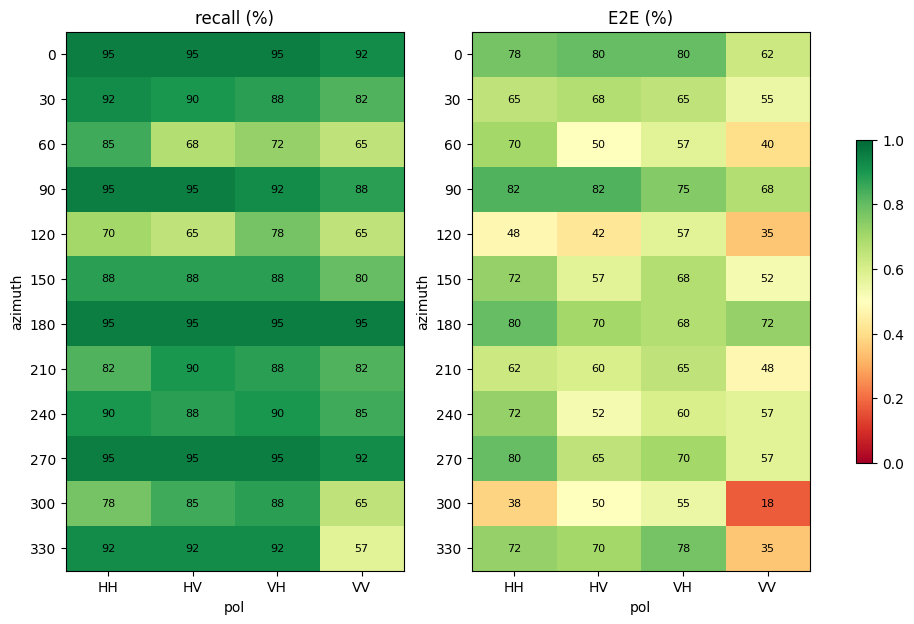

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def heat(ax, piv, title):
    im = ax.imshow(piv.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns)
    ax.set_yticks(range(len(piv.index)));   ax.set_yticklabels(piv.index)
    ax.set_xlabel("pol"); ax.set_ylabel("azimuth"); ax.set_title(title)
    for r in range(piv.shape[0]):
        for c in range(piv.shape[1]):
            v = piv.values[r, c]
            if not np.isnan(v):
                ax.text(c, r, f"{v*100:.0f}", ha="center", va="center", fontsize=8)
    return im

fig, axes = plt.subplots(1, 2, figsize=(12, 7))
heat(axes[0], df.pivot_table(index="azi", columns="pol", values="recall"), "recall (%)")
im = heat(axes[1], df.pivot_table(index="azi", columns="pol", values="E2E"), "E2E (%)")
fig.colorbar(im, ax=axes, shrink=0.6)
plt.show()

## 해석 가이드
- **방위각 행이 고르게 초록** → 회전 보정이 48장 전반에서 작동 (90°배수·off-axis 모두).
- **off-axis(60/120/210/240/300)가 여전히 낮으면** → 90° 스냅이 남기는 30° 잔차 (분류기 한계).
  다음 단계: 분류기를 ConvNeXt/SARATR-X로 교체(셀 3) 또는 분류 크롭 미세회전/TTA.
- **VV 열만 통째로 낮으면** → VV 후방산란이 약한 장면 특성 (recall부터 낮은지 확인).

## 다음 단계
1. 분류기 ConvNeXt/SARATR-X 교체 후 이 노트북 재실행 → CSV 파일명만 바꿔 비교
2. off-axis 분류 회복용 미세회전/TTA 실험